# Navier-Stokes Uncertainty Visualization

## Problem Setup
The governing 2D incompressible Navier-Stokes equations considered here are:

$$
u_t + \lambda_1 (u u_x + v u_y) = -p_x + \lambda_2 (u_{xx} + u_{yy}),
$$

$$
v_t + \lambda_1 (u v_x + v v_y) = -p_y + \lambda_2 (v_{xx} + v_{yy}),
$$

$$
u_x + v_y = 0.
$$

TO-do-list \lambda1 \lambda2

In the current implementation, the PDE parameters are treated as known constants:

$$
\lambda_1 = 1.0, \qquad \lambda_2 = 0.01.
$$

The network predicts the stream function $\psi(x, y, t)$ and pressure $p(x, y, t)$, and the velocity field is recovered through

$$
u = \psi_y, \qquad v = -\psi_x,
$$

so that the incompressibility constraint is satisfied automatically.

The dataset domain used here is:

$$
x \in [1, 8], \qquad y \in [-2, 2], \qquad t \in [0, 19.9].
$$

The reference dataset contains `n_space = 5000` spatial points and `n_time = 200` time snapshots.

## Experiments
I study **how the reconstruction behavior of a Navier-Stokes PINN changes when the training observations contain different types of uncertainty under different weighted losses**.

The discovered uncertainty settings are:

1. `none`: no perturbation is added
2. `cosine_0.300`, `cosine_0.500`, `cosine_0.800`: only cosine observation bias is added, while the cosine-bias amplitude varies across `0.3 / 0.5 / 0.8`; the exact mathematical form is given below
3. `gaussian_0.050`: only `5%` Gaussian noise is added
4. `gaussian_0.050_cosine_0.300`, `gaussian_0.050_cosine_0.500`, `gaussian_0.050_cosine_0.800`: `5%` Gaussian noise and Cosine bias both are added.

For each uncertainty setting, I compare multiple values of `loss_weight`: `0.0 / 0.2 / 0.5 / 0.8 / 1.0`.

The training objective is

$$
\mathcal{L} = w \, \mathcal{L}_{data} + (1-w) \, \mathcal{L}_{PDE}.
$$

## Training Data and Observation Corruption

The original reference data come from the PDE solution stored in `cylinder_nektar_wake.mat`, which consists of spatiotemporal tuples `(x, y, t, u, v, p)`.

The observation corruption is applied to the **velocity observations** only.
- Gaussian noise is added to `u` and `v`
- cosine bias is added to `u` and `v`

The cosine observation bias is injected in the form

$$
 u_{\mathrm{obs}}(x,y,t) = u_{\mathrm{true}}(x,y,t) + b \cos(x + 2y),
  \to_do_list u_{\mathrm{obs}}(x,y,t) = u_{\mathrm{true}}(x,y,t) + b \sin(x + 2y),
$$

$$
 v_{\mathrm{obs}}(x,y,t) = v_{\mathrm{true}}(x,y,t) + b \cos(x + 2y),
$$

where `b` is the bias level, for example `0.3`, `0.5`, or `0.8` in the current experiments.

The corrupted observation dataset is saved to the local observation cache: `/data/pinns/data/cached_observation_data/navier_stokes_uncertainty/`

During training, the current implementation samples 5000 spatiotemporal observation points from the cached observation dataset. These sampled points are used in the data loss term. The PDE residual is evaluated on the **same sampled spatiotemporal points**.

This notebook currently serves three purposes:

1. Load and visualize the locally saved observation cache
2. Load checkpoints trained under different uncertainty settings and loss weights
3. Compare the resulting PINN predictions at a selected time slice


In [11]:
from pathlib import Path
import importlib.util
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

NOTEBOOK_DIR = Path('/data/pinns/notebooks')
SCRIPT_PATH = NOTEBOOK_DIR / 'Navier-Stokes-uncertainty.py'
OUTPUT_ROOT = Path('/data/pinns/outputs/navier_stokes_uncertainty')
CHECKPOINT_ROOT = Path('/data/pinns/checkpoints/navier_stokes_uncertainty')

spec = importlib.util.spec_from_file_location('ns_uncertainty', SCRIPT_PATH)
nsu = importlib.util.module_from_spec(spec)
spec.loader.exec_module(nsu)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(nsu.DTYPE)
device


device(type='cuda')

## Part 1. Visualize all cached corrupted observation datasets

Before comparing checkpoints, I first visualize all cached observation datasets that are currently available under the uncertainty experiments.

This section focuses only on the **training observations** after corruption, not on the PINN predictions.
The plots in this section show a **single time slice** at `PLOT_T_IDX = 100`.
For each automatically discovered uncertainty setting, I visualize:

- the original reference field from the PDE dataset
- the corrupted observation field after adding Gaussian noise and/or cosine bias
- the difference between the corrupted observation and the reference field


In [12]:
reference = nsu.load_reference_solution(nsu.MAT_PATH)
flat_reference = nsu.flatten_reference(reference)

PLOT_T_IDX = 100

n_space = reference['x'].shape[0]
n_time = reference['t'].shape[0]
nx = np.unique(reference['x'][:, 0]).size
ny = np.unique(reference['y'][:, 0]).size
x_grid = reference['x'].reshape(ny, nx)
y_grid = reference['y'].reshape(ny, nx)

AVAILABLE_RUNS = sorted(
    path.name
    for path in CHECKPOINT_ROOT.iterdir()
    if path.is_dir() and (path / 'model.pt').exists() and (OUTPUT_ROOT / path.name / 'metrics.json').exists()
)

def load_metrics(run_name: str) -> dict:
    return json.loads((OUTPUT_ROOT / run_name / 'metrics.json').read_text())

ALL_METRICS_BY_RUN = {run_name: load_metrics(run_name) for run_name in AVAILABLE_RUNS}

def scenario_tuple_from_metrics(metrics: dict) -> tuple[str, float, str, float]:
    return (
        metrics['noise_type'],
        float(metrics['noise_level']),
        metrics['bias_type'],
        float(metrics['bias_level']),
    )

def scenario_label_from_tuple(scenario: tuple[str, float, str, float]) -> str:
    noise_type, noise_level, bias_type, bias_level = scenario
    parts = []
    if noise_type != 'none' and noise_level > 0:
        parts.append(f'{noise_type}_{noise_level:.3f}')
    if bias_type != 'none' and bias_level > 0:
        parts.append(f'{bias_type}_{bias_level:.3f}')
    return 'none' if not parts else '_'.join(parts)

def scenario_sort_key(item: tuple[str, list[str]]) -> tuple[int, str]:
    label, _ = item
    return (0 if label == 'none' else 1, label)

SCENARIO_GROUPS = {}
for run_name, metrics in ALL_METRICS_BY_RUN.items():
    label = scenario_label_from_tuple(scenario_tuple_from_metrics(metrics))
    SCENARIO_GROUPS.setdefault(label, []).append(run_name)

for label, run_names in SCENARIO_GROUPS.items():
    run_names.sort(key=lambda name: (ALL_METRICS_BY_RUN[name]['loss_weight'], name))

SCENARIO_GROUPS = dict(sorted(SCENARIO_GROUPS.items(), key=scenario_sort_key))
SCENARIO_REPRESENTATIVE_RUN = {label: run_names[0] for label, run_names in SCENARIO_GROUPS.items()}

u_true_grid = reference['u'][:, PLOT_T_IDX : PLOT_T_IDX + 1].reshape(ny, nx)
v_true_grid = reference['v'][:, PLOT_T_IDX : PLOT_T_IDX + 1].reshape(ny, nx)
p_true_grid = reference['p'][:, PLOT_T_IDX : PLOT_T_IDX + 1].reshape(ny, nx)

def slice_from_flat(flat: dict[str, np.ndarray], key: str, plot_t_idx: int) -> np.ndarray:
    return flat[key].reshape(n_space, n_time)[:, plot_t_idx : plot_t_idx + 1]

def load_observation_from_run(run_name: str) -> tuple[Path, dict[str, np.ndarray]]:
    observation_cache_path = Path(ALL_METRICS_BY_RUN[run_name]['observation_cache_path'])
    cached = np.load(observation_cache_path)
    flat_observation = {key: cached[key] for key in ['x', 'y', 't', 'u', 'v', 'p']}
    return observation_cache_path, flat_observation

print(f't = {float(reference["t"][PLOT_T_IDX, 0]):.3f}')
print(f'Total checkpoints discovered: {len(AVAILABLE_RUNS)}')
print(f'Total observation scenarios discovered: {len(SCENARIO_GROUPS)}')
print('Scenarios:', list(SCENARIO_GROUPS.keys()))


t = 10.000
Total checkpoints discovered: 40
Total observation scenarios discovered: 8
Scenarios: ['none', 'cosine_0.300', 'cosine_0.500', 'cosine_0.800', 'gaussian_0.050', 'gaussian_0.050_cosine_0.300', 'gaussian_0.050_cosine_0.500', 'gaussian_0.050_cosine_0.800']


In [13]:
dataset_table = pd.DataFrame([
    {
        'scenario': scenario_name,
        'representative_run': SCENARIO_REPRESENTATIVE_RUN[scenario_name],
        'n_runs': len(SCENARIO_GROUPS[scenario_name]),
        'observation_cache_path': str(Path(ALL_METRICS_BY_RUN[SCENARIO_REPRESENTATIVE_RUN[scenario_name]]['observation_cache_path'])),
    }
    for scenario_name in SCENARIO_GROUPS
]).sort_values('scenario').reset_index(drop=True)

dataset_table


,scenario,representative_run,n_runs,observation_cache_path
0,cosine_0.300,lw_0p000_cosine_0p300,5,/data/pinns/data/cached_observation_data/navie...
1,cosine_0.500,lw_0p000_cosine_0p500,5,/data/pinns/data/cached_observation_data/navie...
2,cosine_0.800,lw_0p000_cosine_0p800,5,/data/pinns/data/cached_observation_data/navie...
3,gaussian_0.050,lw_0p000_gaussian_0p050,5,/data/pinns/data/cached_observation_data/navie...
4,gaussian_0.050_cosine_0.300,lw_0p000_gaussian_0p050_cosine_0p300,5,/data/pinns/data/cached_observation_data/navie...
5,gaussian_0.050_cosine_0.500,lw_0p000_gaussian_0p050_cosine_0p500,5,/data/pinns/data/cached_observation_data/navie...
6,gaussian_0.050_cosine_0.800,lw_0p000_gaussian_0p050_cosine_0p800,5,/data/pinns/data/cached_observation_data/navie...
7,none,lw_0p000,5,/data/pinns/data/cached_observation_data/navie...


In [14]:
def plot_dataset_comparison(field_key: str, scenario_names: list[str] | None = None, plot_t_idx: int = PLOT_T_IDX) -> None:
    if scenario_names is None:
        scenario_names = list(SCENARIO_GROUPS.keys())

    if field_key == 'u':
        ref_grid = reference['u'][:, plot_t_idx : plot_t_idx + 1].reshape(ny, nx)
    elif field_key == 'v':
        ref_grid = reference['v'][:, plot_t_idx : plot_t_idx + 1].reshape(ny, nx)
    else:
        raise ValueError("field_key must be either 'u' or 'v'.")

    panels = [('reference', ref_grid)]
    for scenario_name in scenario_names:
        representative_run = SCENARIO_REPRESENTATIVE_RUN[scenario_name]
        _, flat_obs = load_observation_from_run(representative_run)
        obs_grid = slice_from_flat(flat_obs, field_key, plot_t_idx).reshape(ny, nx)
        panels.append((scenario_name, obs_grid))

    ncols = len(panels)
    fig, axes = plt.subplots(2, ncols, figsize=(4.5 * ncols, 8), constrained_layout=True)
    if ncols == 1:
        axes = np.array(axes).reshape(2, 1)

    ref_vmin = float(ref_grid.min())
    ref_vmax = float(ref_grid.max())

    for col, (label, grid) in enumerate(panels):
        mesh = axes[0, col].pcolormesh(x_grid, y_grid, grid, shading='auto', cmap='coolwarm', vmin=ref_vmin, vmax=ref_vmax)
        axes[0, col].set_title(f'{field_key}: {label}')
        axes[0, col].set_xlabel('x')
        axes[0, col].set_ylabel('y')
        plt.colorbar(mesh, ax=axes[0, col], shrink=0.9)

        delta = grid - ref_grid
        mesh = axes[1, col].pcolormesh(x_grid, y_grid, delta, shading='auto', cmap='coolwarm')
        axes[1, col].set_title(f'{field_key} delta: {label} - reference')
        axes[1, col].set_xlabel('x')
        axes[1, col].set_ylabel('y')
        plt.colorbar(mesh, ax=axes[1, col], shrink=0.9)

    plt.show()


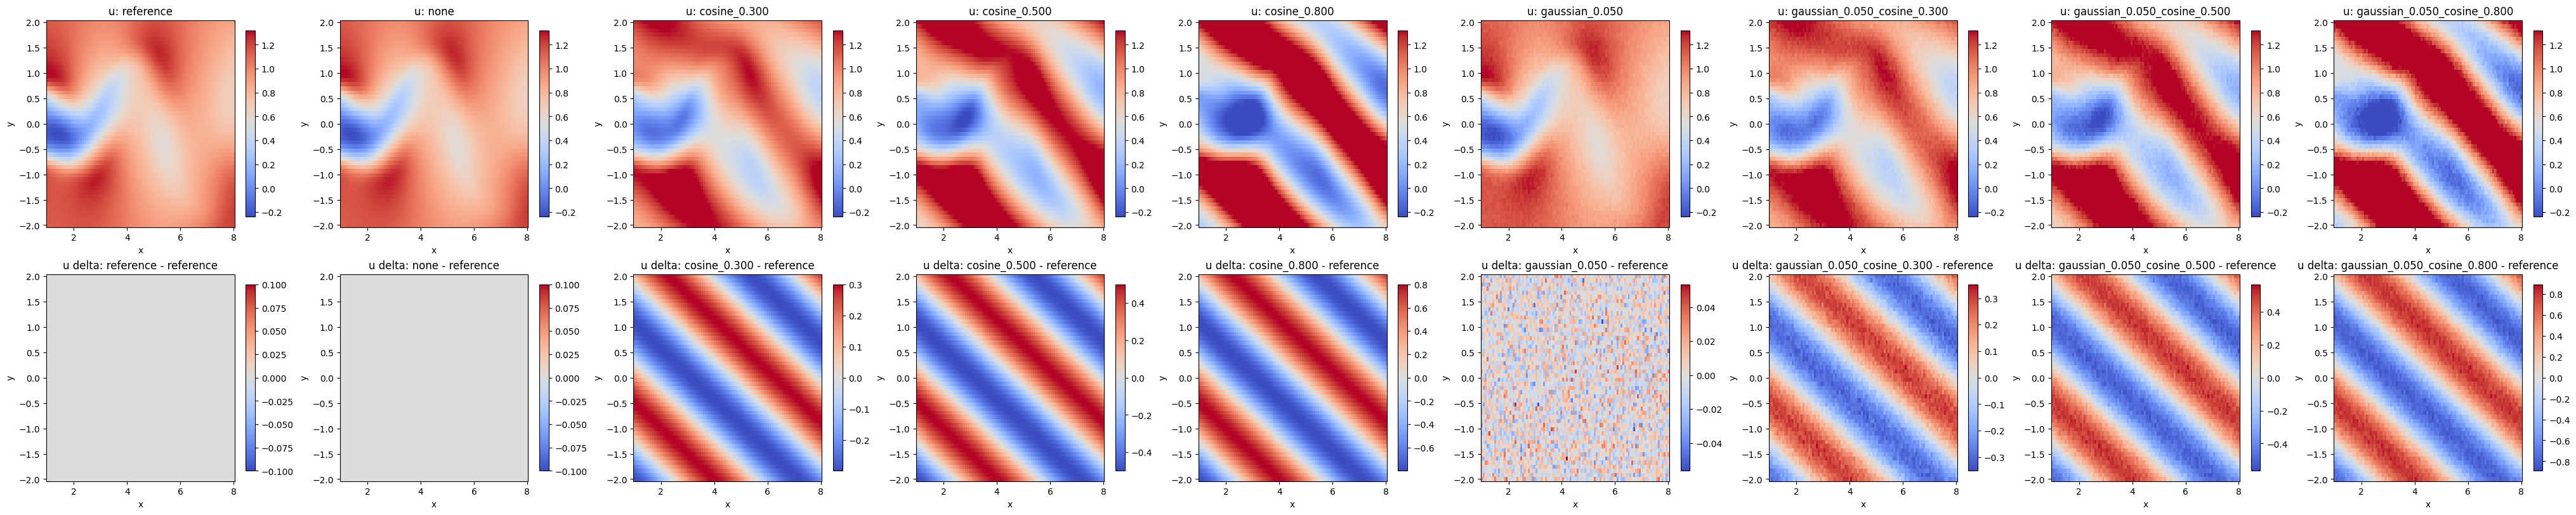

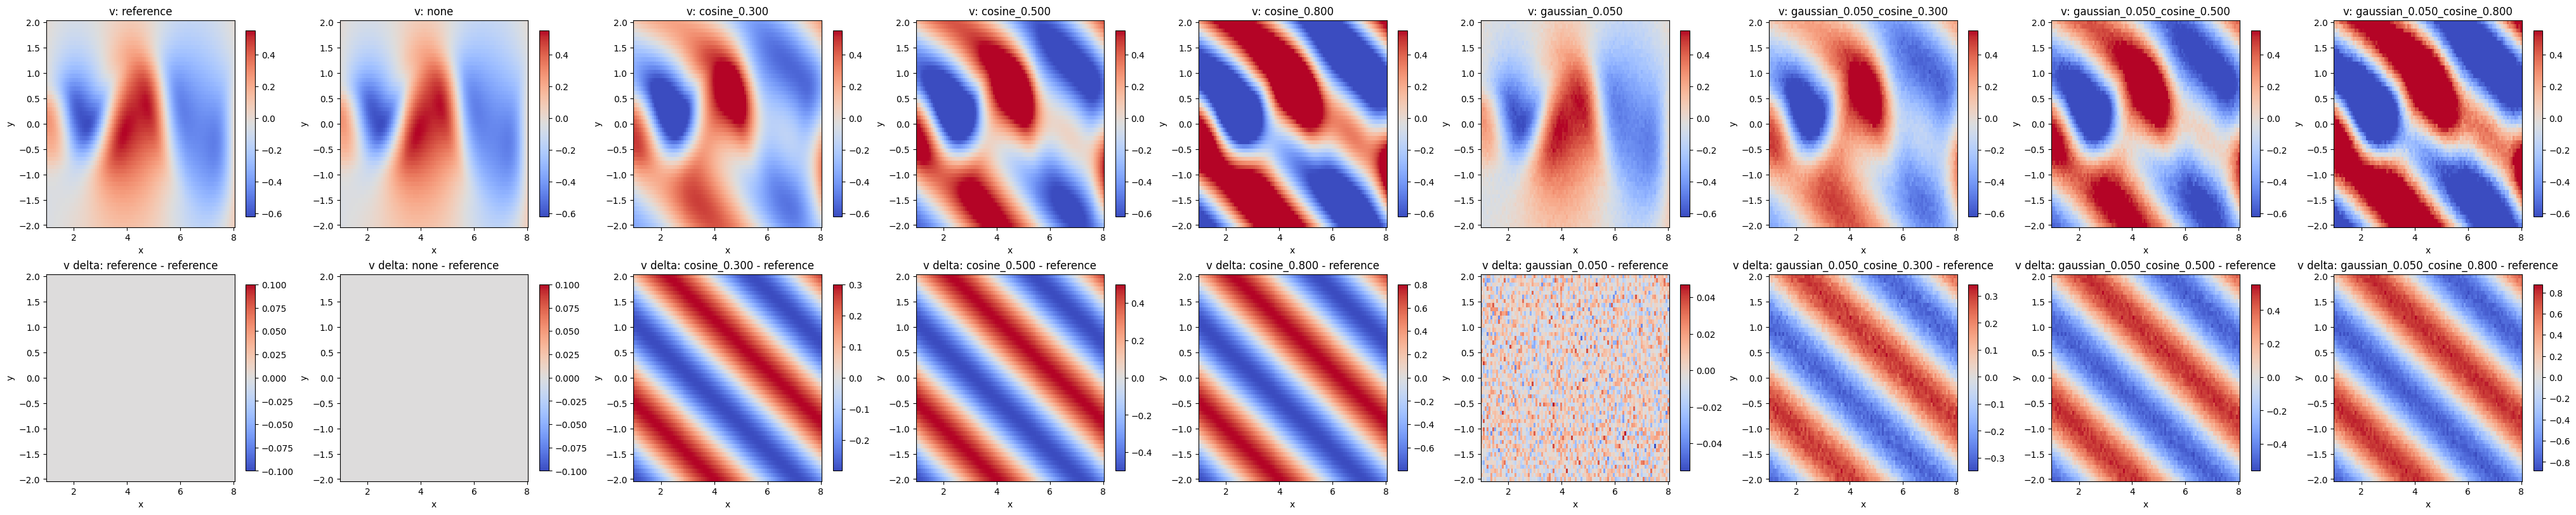

In [15]:
plot_dataset_comparison('u')
plot_dataset_comparison('v')


## Part 2. Visualize prediction results for all discovered checkpoints

In this part, the notebook automatically discovers all available checkpoints under `/data/pinns/outputs/navier_stokes_uncertainty/` and visualizes them one by one.

For every checkpoint, the notebook plots a 3 x 4 panel:

- the first row shows `u(x, y)`: Reference / Observation / Prediction / Absolute error
- the second row shows `v(x, y)`: Reference / Observation / Prediction / Absolute error
- the third row shows `p(x, y)`: Reference / Prediction / Absolute error / blank

For `u` and `v`, the reference, observation, and prediction share the observation-based color scale. The absolute-error panel uses its own color scale. For `p`, the reference and prediction share the reference-based color scale, while the absolute-error panel again uses its own color scale.

Each figure is also saved automatically to the corresponding run folder.


In [16]:
ALL_RUNS = sorted(
    AVAILABLE_RUNS,
    key=lambda name: (
        scenario_label_from_tuple(scenario_tuple_from_metrics(ALL_METRICS_BY_RUN[name])),
        ALL_METRICS_BY_RUN[name]['loss_weight'],
        name,
    ),
)

SCENARIO_FILTER = 'all'  # set to one of dataset_table['scenario'] if you only want a subset
if SCENARIO_FILTER == 'all':
    SELECTED_RUNS = ALL_RUNS
else:
    SELECTED_RUNS = [
        run_name
        for run_name in ALL_RUNS
        if scenario_label_from_tuple(scenario_tuple_from_metrics(ALL_METRICS_BY_RUN[run_name])) == SCENARIO_FILTER
    ]

print('Scenario filter:', SCENARIO_FILTER)
print('Number of selected runs:', len(SELECTED_RUNS))
print('Selected runs:', SELECTED_RUNS)


Scenario filter: all
Number of selected runs: 40
Selected runs: ['lw_0p000_cosine_0p300', 'lw_0p200_cosine_0p300', 'lw_0p500_cosine_0p300', 'lw_0p800_cosine_0p300', 'lw_1p000_cosine_0p300', 'lw_0p000_cosine_0p500', 'lw_0p200_cosine_0p500', 'lw_0p500_cosine_0p500', 'lw_0p800_cosine_0p500', 'lw_1p000_cosine_0p500', 'lw_0p000_cosine_0p800', 'lw_0p200_cosine_0p800', 'lw_0p500_cosine_0p800', 'lw_0p800_cosine_0p800', 'lw_1p000_cosine_0p800', 'lw_0p000_gaussian_0p050', 'lw_0p200_gaussian_0p050', 'lw_0p500_gaussian_0p050', 'lw_0p800_gaussian_0p050', 'lw_1p000_gaussian_0p050', 'lw_0p000_gaussian_0p050_cosine_0p300', 'lw_0p200_gaussian_0p050_cosine_0p300', 'lw_0p500_gaussian_0p050_cosine_0p300', 'lw_0p800_gaussian_0p050_cosine_0p300', 'lw_1p000_gaussian_0p050_cosine_0p300', 'lw_0p000_gaussian_0p050_cosine_0p500', 'lw_0p200_gaussian_0p050_cosine_0p500', 'lw_0p500_gaussian_0p050_cosine_0p500', 'lw_0p800_gaussian_0p050_cosine_0p500', 'lw_1p000_gaussian_0p050_cosine_0p500', 'lw_0p000_gaussian_0p050_

In [17]:
def build_metrics_table(run_names: list[str]) -> tuple[dict[str, dict], pd.DataFrame]:
    metrics_by_run = {run_name: ALL_METRICS_BY_RUN[run_name] for run_name in run_names}
    metrics_table = pd.DataFrame([
        {
            'run_name': run_name,
            'scenario': scenario_label_from_tuple(scenario_tuple_from_metrics(metrics)),
            'loss_weight': metrics['loss_weight'],
            'pde_weight': metrics['pde_weight'],
            'noise_type': metrics['noise_type'],
            'noise_level': metrics['noise_level'],
            'bias_type': metrics['bias_type'],
            'bias_level': metrics['bias_level'],
            'rel_l2_u': metrics['rel_l2_u'],
            'rel_l2_v': metrics['rel_l2_v'],
            'rel_l2_p': metrics['rel_l2_p'],
            'observation_cache_hit': metrics['observation_cache_hit'],
        }
        for run_name, metrics in metrics_by_run.items()
    ]).sort_values(['scenario', 'loss_weight', 'run_name']).reset_index(drop=True)
    return metrics_by_run, metrics_table

metrics_by_run, metrics_table = build_metrics_table(SELECTED_RUNS)
metrics_table


,run_name,scenario,loss_weight,pde_weight,noise_type,noise_level,bias_type,bias_level,rel_l2_u,rel_l2_v,rel_l2_p,observation_cache_hit
0,lw_0p000_cosine_0p300,cosine_0.300,0.0,1.0,none,0.00,cosine,0.3,0.999008,0.999981,0.781048,False
1,lw_0p200_cosine_0p300,cosine_0.300,0.2,0.8,none,0.00,cosine,0.3,0.116507,0.310774,1.671379,True
2,lw_0p500_cosine_0p300,cosine_0.300,0.5,0.5,none,0.00,cosine,0.3,0.125366,0.271881,1.977615,True
3,lw_0p800_cosine_0p300,cosine_0.300,0.8,0.2,none,0.00,cosine,0.3,0.139192,0.282686,0.964997,True
4,lw_1p000_cosine_0p300,cosine_0.300,1.0,0.0,none,0.00,cosine,0.3,0.164180,0.370798,4.863197,True
5,lw_0p000_cosine_0p500,cosine_0.500,0.0,1.0,none,0.00,cosine,0.5,0.999008,0.999981,0.781048,False
6,lw_0p200_cosine_0p500,cosine_0.500,0.2,0.8,none,0.00,cosine,0.5,0.251919,1.053806,1.124297,True
7,lw_0p500_cosine_0p500,cosine_0.500,0.5,0.5,none,0.00,cosine,0.5,0.213515,0.466443,1.177881,True
8,lw_0p800_cosine_0p500,cosine_0.500,0.8,0.2,none,0.00,cosine,0.5,0.237323,0.486021,1.196370,True
9,lw_1p000_cosine_0p500,cosine_0.500,1.0,0.0,none,0.00,cosine,0.5,0.286156,0.699271,7.696322,True


In [18]:
selected_run_table = pd.DataFrame([
    {
        'run_name': run_name,
        'scenario': scenario_label_from_tuple(scenario_tuple_from_metrics(metrics_by_run[run_name])),
        'loss_weight': metrics_by_run[run_name]['loss_weight'],
        'observation_cache_path': metrics_by_run[run_name]['observation_cache_path'],
    }
    for run_name in SELECTED_RUNS
]).sort_values(['scenario', 'loss_weight', 'run_name']).reset_index(drop=True)

selected_run_table


,run_name,scenario,loss_weight,observation_cache_path
0,lw_0p000_cosine_0p300,cosine_0.300,0.0,/data/pinns/data/cached_observation_data/navie...
1,lw_0p200_cosine_0p300,cosine_0.300,0.2,/data/pinns/data/cached_observation_data/navie...
2,lw_0p500_cosine_0p300,cosine_0.300,0.5,/data/pinns/data/cached_observation_data/navie...
3,lw_0p800_cosine_0p300,cosine_0.300,0.8,/data/pinns/data/cached_observation_data/navie...
4,lw_1p000_cosine_0p300,cosine_0.300,1.0,/data/pinns/data/cached_observation_data/navie...
5,lw_0p000_cosine_0p500,cosine_0.500,0.0,/data/pinns/data/cached_observation_data/navie...
6,lw_0p200_cosine_0p500,cosine_0.500,0.2,/data/pinns/data/cached_observation_data/navie...
7,lw_0p500_cosine_0p500,cosine_0.500,0.5,/data/pinns/data/cached_observation_data/navie...
8,lw_0p800_cosine_0p500,cosine_0.500,0.8,/data/pinns/data/cached_observation_data/navie...
9,lw_1p000_cosine_0p500,cosine_0.500,1.0,/data/pinns/data/cached_observation_data/navie...


In [19]:
OBSERVATION_RUN = SELECTED_RUNS[0]

def load_observation_from_run(run_name: str) -> tuple[Path, dict[str, np.ndarray]]:
    observation_cache_path = Path(metrics_by_run[run_name]['observation_cache_path'])
    cached = np.load(observation_cache_path)
    flat_observation = {key: cached[key] for key in ['x', 'y', 't', 'u', 'v', 'p']}
    return observation_cache_path, flat_observation

observation_cache_path, flat_observation = load_observation_from_run(OBSERVATION_RUN)
u_obs_grid = slice_from_flat(flat_observation, 'u', PLOT_T_IDX).reshape(ny, nx)
v_obs_grid = slice_from_flat(flat_observation, 'v', PLOT_T_IDX).reshape(ny, nx)

print(f'Observation run: {OBSERVATION_RUN}')
print(f'Observation cache: {observation_cache_path}')
print(f't = {float(reference["t"][PLOT_T_IDX, 0]):.3f}')


Observation run: lw_0p000_cosine_0p300
Observation cache: /data/pinns/data/cached_observation_data/navier_stokes_uncertainty/seed_1234__noise_none_0p000__bias_cosine_0p300.npz
t = 10.000


In [20]:
def infer_layers_from_state_dict(state_dict: dict[str, torch.Tensor]) -> tuple[int, ...]:
    weight_keys = sorted(
        [key for key in state_dict if key.startswith('net.') and key.endswith('.weight')],
        key=lambda key: int(key.split('.')[1]),
    )
    layers = [state_dict[weight_keys[0]].shape[1]]
    for key in weight_keys:
        layers.append(state_dict[key].shape[0])
    return tuple(int(x) for x in layers)

def load_model_for_run(run_name: str, device: torch.device) -> nsu.NavierStokesPINN:
    ckpt_path = CHECKPOINT_ROOT / run_name / 'model.pt'
    checkpoint = torch.load(ckpt_path, map_location=device)
    state_dict = checkpoint['model_state_dict']
    layers = infer_layers_from_state_dict(state_dict)
    lb = tuple(float(x) for x in state_dict['lb'].cpu().tolist())
    ub = tuple(float(x) for x in state_dict['ub'].cpu().tolist())

    model = nsu.NavierStokesPINN(layers=layers, lb=lb, ub=ub).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def predict_slice(run_name: str, plot_t_idx: int = PLOT_T_IDX, device: torch.device = device) -> dict[str, np.ndarray]:
    model = load_model_for_run(run_name, device)
    x_slice = reference['x']
    y_slice = reference['y']
    t_slice = np.full_like(x_slice, float(reference['t'][plot_t_idx, 0]))
    u_pred, v_pred, p_pred = nsu.predict_chunk(model, x_slice, y_slice, t_slice, device)
    p_true = reference['p'][:, plot_t_idx : plot_t_idx + 1]
    p_pred_aligned = p_pred - np.mean(p_pred - p_true)
    return {
        'u': u_pred.reshape(ny, nx),
        'v': v_pred.reshape(ny, nx),
        'p': p_pred_aligned.reshape(ny, nx),
    }


In [21]:
def plot_single_run_overview(run_name: str, plot_t_idx: int = PLOT_T_IDX, save: bool = True) -> Path | None:
    if run_name not in metrics_by_run:
        raise ValueError(f'Unknown run: {run_name}')

    loss_weight = metrics_by_run[run_name]['loss_weight']
    _, flat_observation_local = load_observation_from_run(run_name)
    prediction = predict_slice(run_name, plot_t_idx=plot_t_idx, device=device)

    u_ref = reference['u'][:, plot_t_idx : plot_t_idx + 1].reshape(ny, nx)
    v_ref = reference['v'][:, plot_t_idx : plot_t_idx + 1].reshape(ny, nx)
    p_ref = reference['p'][:, plot_t_idx : plot_t_idx + 1].reshape(ny, nx)

    u_obs = slice_from_flat(flat_observation_local, 'u', plot_t_idx).reshape(ny, nx)
    v_obs = slice_from_flat(flat_observation_local, 'v', plot_t_idx).reshape(ny, nx)

    u_err = np.abs(prediction['u'] - u_ref)
    v_err = np.abs(prediction['v'] - v_ref)
    p_err = np.abs(prediction['p'] - p_ref)

    fig, axes = plt.subplots(3, 4, figsize=(18, 12), constrained_layout=True)
    fig.suptitle(
        f'Run: {run_name} | loss_weight = {loss_weight:.1f} | t = {float(reference["t"][plot_t_idx, 0]):.3f}',
        fontsize=14,
    )

    u_vmin = float(u_obs.min())
    u_vmax = float(u_obs.max())
    for ax, field, title, vmin, vmax in [
        (axes[0, 0], u_ref, 'Reference u(x, y)', u_vmin, u_vmax),
        (axes[0, 1], u_obs, 'Observation u(x, y)', u_vmin, u_vmax),
        (axes[0, 2], prediction['u'], 'Prediction u(x, y)', u_vmin, u_vmax),
        (axes[0, 3], u_err, 'Absolute error u(x, y)', None, None),
    ]:
        mesh = ax.pcolormesh(x_grid, y_grid, field, shading='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        plt.colorbar(mesh, ax=ax, shrink=0.9)

    v_vmin = float(v_obs.min())
    v_vmax = float(v_obs.max())
    for ax, field, title, vmin, vmax in [
        (axes[1, 0], v_ref, 'Reference v(x, y)', v_vmin, v_vmax),
        (axes[1, 1], v_obs, 'Observation v(x, y)', v_vmin, v_vmax),
        (axes[1, 2], prediction['v'], 'Prediction v(x, y)', v_vmin, v_vmax),
        (axes[1, 3], v_err, 'Absolute error v(x, y)', None, None),
    ]:
        mesh = ax.pcolormesh(x_grid, y_grid, field, shading='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        plt.colorbar(mesh, ax=ax, shrink=0.9)

    p_vmin = float(p_ref.min())
    p_vmax = float(p_ref.max())
    for ax, field, title, vmin, vmax in [
        (axes[2, 0], p_ref, 'Reference p(x, y)', p_vmin, p_vmax),
        (axes[2, 1], prediction['p'], 'Prediction p(x, y)', p_vmin, p_vmax),
        (axes[2, 2], p_err, 'Absolute error p(x, y)', None, None),
    ]:
        mesh = ax.pcolormesh(x_grid, y_grid, field, shading='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        plt.colorbar(mesh, ax=ax, shrink=0.9)

    axes[2, 3].axis('off')

    save_path = None
    if save:
        save_path = OUTPUT_ROOT / run_name / f'notebook_overview_t{plot_t_idx:03d}.png'
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()
    return save_path


In [22]:
def visualize_selected_runs(run_names: list[str], plot_t_idx: int = PLOT_T_IDX, save: bool = True) -> list[Path | None]:
    saved_paths = []
    for run_name in run_names:
        saved_paths.append(plot_single_run_overview(run_name, plot_t_idx=plot_t_idx, save=save))
    return saved_paths


In [ ]:
# One-click visualization: visualize and save all selected checkpoints
saved_paths = visualize_selected_runs(SELECTED_RUNS, plot_t_idx=PLOT_T_IDX, save=True)
print(f'Saved {len(saved_paths)} figures.')
saved_paths[:5]

In [24]:
# Example: only visualize one scenario
# SCENARIO_FILTER = 'gaussian_0.050_cosine_0.500'
# SELECTED_RUNS = [run_name for run_name in ALL_RUNS if scenario_label_from_tuple(scenario_tuple_from_metrics(ALL_METRICS_BY_RUN[run_name])) == SCENARIO_FILTER]
# visualize_selected_runs(SELECTED_RUNS, plot_t_idx=100, save=True)


In [25]:
# You can still call plot_dataset_comparison('u') or plot_dataset_comparison('v') to inspect all cached observation datasets.
